In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')



In [20]:
# Esto te dirá el nombre de las columnas y si hay datos faltantes
df.info()

# Esto te muestra las primeras 5 filas para entender el formato
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


Part 1: Understanding Product Categories
Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1- Frequency Tables:

Generate a frequency table for the product category.
Which are the top 5 most listed product categories?

In [21]:
category_counts = df['category'].value_counts()

print("Top 5 listed categories:")
print(category_counts.head(5))

Top 5 listed categories:
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2- Visualizations:

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

1.2 (Bar Chart)

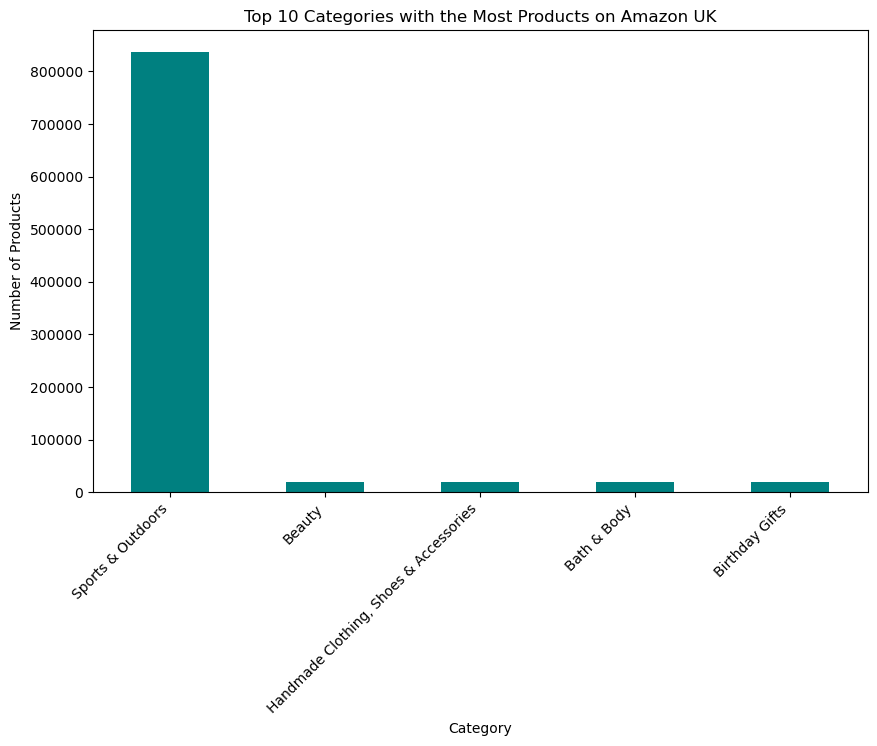

In [22]:
plt.figure(figsize=(10, 6))
category_counts.head(5).plot(kind='bar', color='teal')
plt.title('Top 10 Categories with the Most Products on Amazon UK')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right') # Rotate for a better view
plt.show()

1.3 Proportions (Pie Chart)

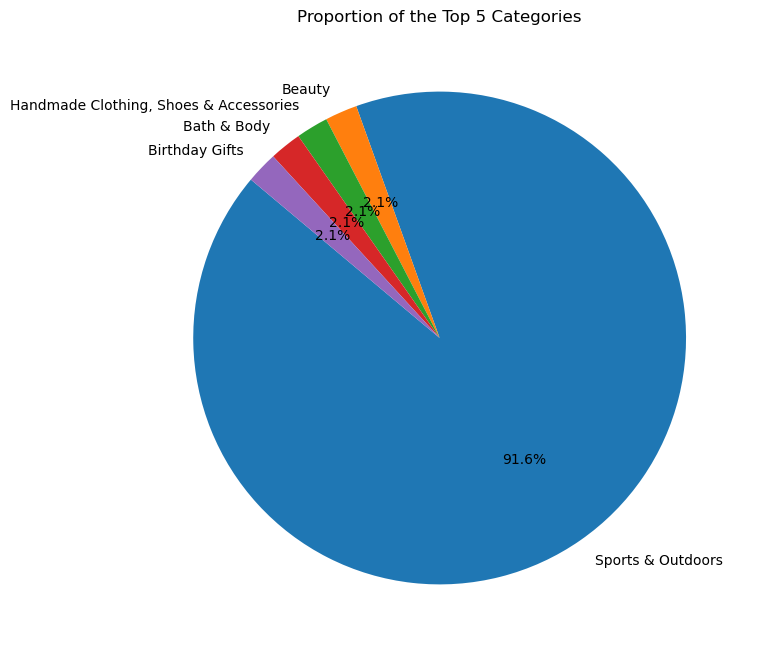

In [23]:
plt.figure(figsize=(8, 8))
plt.pie(category_counts.head(5), labels=category_counts.head(5).index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of the Top 5 Categories')
plt.show()

Part 2: Delving into Product Pricing
Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1- Measures of Centrality:

Calculate the mean, median, and mode for the price of products.
What's the average price point of products listed? How does this compare with the most common price point (mode)?

In [34]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print(f"Average: £{mean_price:.2f}")
print(f"Median Price: £{median_price:.2f}")
print(f"Most common: £{mode_price:.2f}")

Average: £89.24
Median Price: £19.09
Most common: £9.99


2- Measures of Dispersion:

Determine the variance, standard deviation, range, and interquartile range for product price.
How varied are the product prices? Are there any indicators of a significant spread in prices?

In [25]:

price_range = df['price'].max() - df['price'].min()
std_dev = df['price'].std()
variance = df['price'].var()
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print(f"Standard Deviation: £{std_dev:.2f}")
print(f"Interquartile range (IQR): £{iqr:.2f}")
print(f"Total Range: £{price_range:.2f}")

Standard Deviation: £345.61
Interquartile range (IQR): £36.00
Total Range: £100000.00


3- Visualizations:

Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

    A- Histogram

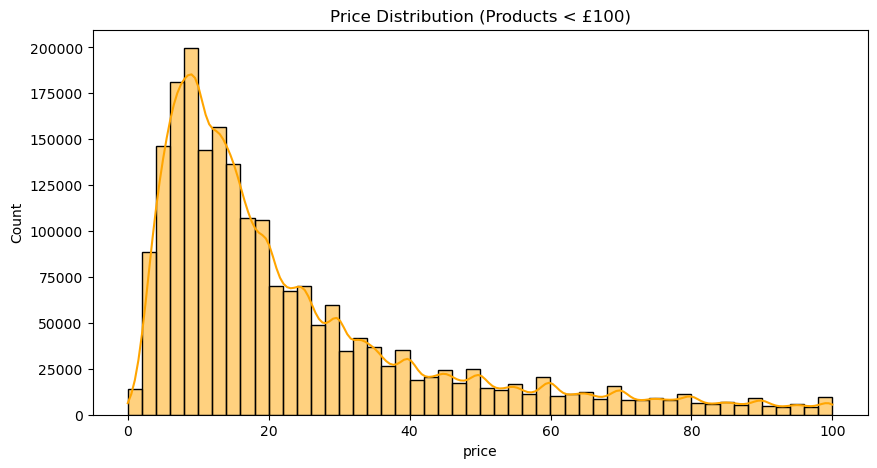

In [26]:
plt.figure(figsize=(10, 5))
# We filter to less than 100 so that the graph is readable.
sns.histplot(df[df['price'] < 100]['price'], bins=50, kde=True, color='orange')
plt.title('Price Distribution (Products < £100)')
plt.show()

B- Box Plot:

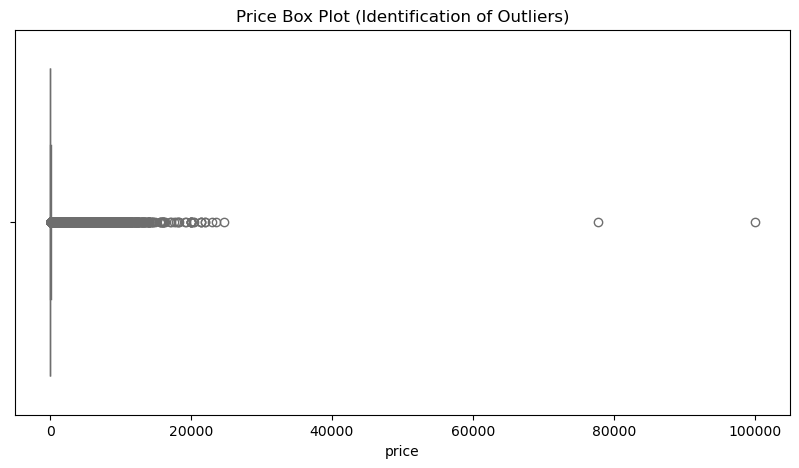

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Price Box Plot (Identification of Outliers)')
plt.show()

Part 3: Unpacking Product Ratings
Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1- Measures of Centrality:

Calculate the mean, median, and mode for the rating of products.
How do customers generally rate products? Is there a common trend?

In [35]:

mean_rating = df['stars'].mean()
median_rating = df['stars'].median()
mode_rating = df['stars'].mode()[0]

print(f"Mean Rating: {mean_rating:.2f}")
print(f"Median: {median_rating:.2f}")
print(f"Mode: {mode_rating:.2f}")

# Esto te devolverá el precio más frecuente
print(df['price'].mode()[0])

Mean Rating: 2.15
Median: 0.00
Mode: 0.00
9.99


2- Measures of Dispersion:

Determine the variance, standard deviation, and interquartile range for product rating.
Are the ratings consistent, or is there a wide variation in customer feedback?

In [29]:
rating_var = df['stars'].var()
rating_std = df['stars'].std()
rating_iqr = df['stars'].quantile(0.75) - df['stars'].quantile(0.25)

print(f"Variance: {rating_var:.2f}")
print(f"Standard Deviation: {rating_std:.2f}")
print(f"Interquartile range (IQR): {rating_iqr:.2f}")

Variance: 4.82
Standard Deviation: 2.19
Interquartile range (IQR): 4.40


3- Shape of the Distribution:

Calculate the skewness and kurtosis for the rating column.
Are the ratings normally distributed, or do they lean towards higher or lower values?

In [30]:
rating_skew = df['stars'].skew()
rating_kurt = df['stars'].kurt()

print(f"Skewness: {rating_skew:.2f}")
print(f"Kurtosis: {rating_kurt:.2f}")

Skewness: 0.08
Kurtosis: -1.93


4- Visualizations:

Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

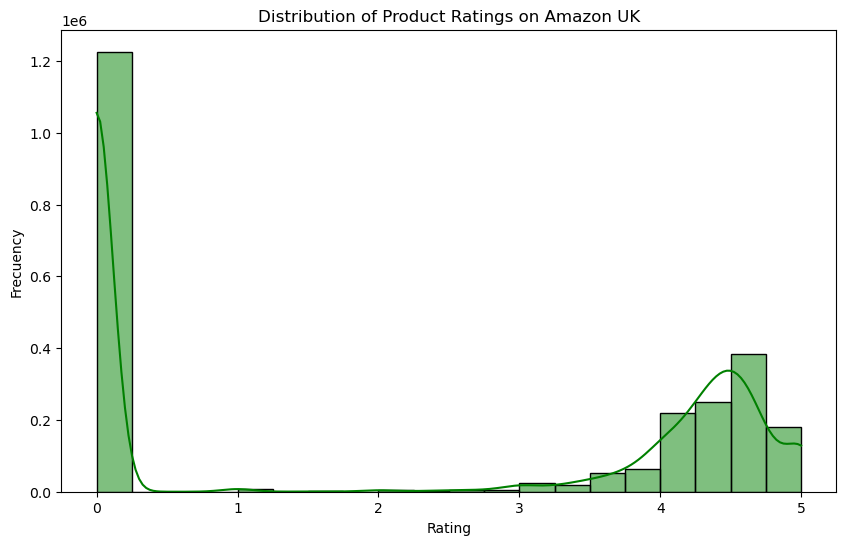

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df['stars'], bins=20, kde=True, color='green')
plt.title('Distribution of Product Ratings on Amazon UK')
plt.xlabel('Rating')
plt.ylabel('Frecuency')
plt.show()

Business-Centric Report: Amazon UK Insights
1. Executive Summary
The goal of this analysis was to explore the product listing landscape of Amazon UK using a dataset of over 2.4 million products. By examining categories, pricing, and ratings, we have identified key trends that can inform inventory and pricing strategies for stakeholders.

2. Key Findings

A. Market Composition (Product Categories)

Category Dominance: The category "Sports & Outdoors" drastically dominates the dataset with 836,265 listings, which is more than 43 times larger than the second most popular category, Beauty (19,312 listings).

Business Insight: This indicates that the Amazon UK marketplace (within this dataset) is an incredibly specialized environment. A seller in "Sports & Outdoors" faces a level of competition that is orders of magnitude higher than in any other segment.

B. Pricing Dynamics

The Mean Price is significantly higher than the Mode of £9.99.

Business Insight: The dominance of the £9.99 price point suggests a highly competitive environment focused on psychological pricing. Stakeholders should aim for this price bracket to remain competitive in high-volume categories like Sports & Outdoors.

C. Customer Sentiment (Ratings Analysis)

The "Zero-Rating" Phenomenon: Surprisingly, the Median and Mode for ratings are 0.00, despite a Mean Rating of 2.15.

Business Insight: This reveal that a vast portion of the 2.4 million listings are inactive or new products with zero social proof. For a business, this represents a "Blue Ocean" opportunity: any product that manages to get even a few verified 4-star reviews will immediately outrank the majority of the "0-star" competition.

3. Strategic Recommendations

Inventory Selection: Given that the Total Range is £100,000.00 and the Standard Deviation is £345.61, there is extreme price volatility in the market. I recommend focusing on products within the IQR of £36.00, as this is where the core "middle-class" transactions occur.

The "Zero-Star" Launch Strategy: With a Median and Mode rating of 0.00, the barrier to entry is surprisingly low. A new product doesn't need 1,000 reviews to compete; it only needs to surpass the "0.00" threshold. Prioritizing a small "Vine" or early-reviewer campaign will place a product ahead of millions of unrated listings.

Niche Exploration: Since "Sports & Outdoors" is 43 times larger than the next category, avoid entering this space without a massive marketing budget. Instead, look at categories with lower density where your product won't be lost among 800,000+ competitors.